In [28]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error,mean_absolute_error
from datetime import datetime

# Construct the path to the database
BASE_DIR = r'C:\Users\91940\Documents\Trade_buddy\scripts'
DB_PATH = os.path.join(BASE_DIR, 'C:/Users/91940/Documents/Trade_buddy/data/processed/stock_data.db')

# Normalize the path to handle '..'
DB_PATH = os.path.normpath(DB_PATH)

TICKER = 'AAPL'
PLOT_PATH = 'C:/Users/91940/Documents/Trade_buddy/data/model_outputs/'

# Fetch stock data
def fetch_stock_data(ticker):
    # Print to confirm the correct path
    print("Database Path:", DB_PATH)
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT date_time, close_price
        FROM stock_data_transformed
        WHERE ticker = ?
        ORDER BY date_time ASC
    """
    data = pd.read_sql(query, conn, params=(ticker,))
    conn.close()
    
    # Convert date_time to datetime and set as index
    data['date_time'] = pd.to_datetime(data['date_time'])
    data.set_index('date_time', inplace=True)
    
    data = data[~data.index.duplicated(keep='first')]
    data = data.asfreq('min', method='ffill')  # 'T' for minute-level frequency

    return data

# Train-test split
def train_test_split(data, test_size=0.2):
    split_idx = int(len(data) * (1 - test_size))
    train, test = data.iloc[:split_idx], data.iloc[split_idx:]
    print(len(data),len(test))
    #plot_acf(train)
    #plot_pacf(train)
    #plt.show()
    return train, test

# Model training and prediction
def train_and_predict(train, test, p=2, d=1, q=10):
    # Train ARIMA model
    model = ARIMA(train, order=(p, d, q))
    fitted_model = model.fit()
    print(f"ARIMA model fitted with order ({p}, {d}, {q})")

    # Predict on test data
    test_pred = fitted_model.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)
    print(test_pred)
    
    # Calculate performance metrics
    mse = mean_squared_error(test, test_pred)
    mae = mean_absolute_error(test, test_pred)
    mape = np.mean(np.abs((test - test_pred) / test)) * 100  # Mean Absolute Percentage Error
    rmspe = np.sqrt(np.mean(np.square((test - test_pred) / test))) * 100  # Root Mean Squared Percentage Error

    # Print performance metrics
    print(f"Test Mean Squared Error (MSE): {mse:.2f}")
    print(f"Test Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Test Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"Test Root Mean Squared Percentage Error (RMSPE): {rmspe:.2f}%")

    # Future forecast
    future_steps = 2  # Define steps for future prediction
    future_pred = fitted_model.forecast(steps=future_steps)

    return test_pred, future_pred, mse, mae, mape, rmspe

def train_and_predict_sarimax(train, test, p=1, d=1, q=1, P=1, D=1, Q=1, s=1440):
    """
    Train SARIMA model on the given train data and predict test and future values.
    
    Args:
        train (pd.Series): Training time series data.
        test (pd.Series): Test time series data.
        p, d, q (int): Non-seasonal ARIMA parameters.
        P, D, Q, s (int): Seasonal parameters and seasonal period.
    
    Returns:
        tuple: Test predictions, future predictions, test MSE.
    """
    # Train the SARIMAX model
    model = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q, s))
    fitted_model = model.fit(disp=False)
    print(f"SARIMA model fitted with order ({p}, {d}, {q}) and seasonal order ({P}, {D}, {Q}, {s})")
    
    # Predict on test data
    test_pred = fitted_model.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)
    mse = mean_squared_error(test, test_pred)
    print(f"Test Mean Squared Error: {mse:.2f}")
    
    # Future forecast
    future_steps = 5  # Define steps for future prediction
    future_pred = fitted_model.forecast(steps=future_steps)
    
    return test_pred, future_pred, mse

# Visualization
def plot_predictions(train, test, test_pred, future_pred):
    plt.figure(figsize=(10, 6))
    plt.plot(train.index, train, label='Train Data', color='blue')
    plt.plot(test.index, test, label='Test Data', color='green')
    plt.plot(test.index, test_pred, label='Test Predictions', color='orange')
    future_index = pd.date_range(test.index[-1] + pd.Timedelta(days=1), periods=len(future_pred), freq='min')
    plt.plot(future_index, future_pred, label='Future Forecast', color='red')

    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.title(f"{TICKER} Stock Price Prediction")
    plt.legend()
    plt.tight_layout()
    file_path = f"{PLOT_PATH}{TICKER}_stock_prediction_{datetime.now().strftime('%Y%m%d')}.png"
    plt.savefig(file_path)
    plt.show()
    print(f"Plot saved at {file_path}")

Database Path: C:\Users\91940\Documents\Trade_buddy\data\processed\stock_data.db
37830 7566
ARIMA model fitted with order (2, 1, 10)
2024-11-22 09:54:00    225.070007
2024-11-22 09:55:00    225.070007
2024-11-22 09:56:00    225.070007
2024-11-22 09:57:00    225.070007
2024-11-22 09:58:00    225.070007
                          ...    
2024-11-27 15:55:00    225.070007
2024-11-27 15:56:00    225.070007
2024-11-27 15:57:00    225.070007
2024-11-27 15:58:00    225.070007
2024-11-27 15:59:00    225.070007
Freq: min, Name: predicted_mean, Length: 7566, dtype: float64
Test Mean Squared Error (MSE): 33.99
Test Mean Absolute Error (MAE): 3.78
Test Mean Absolute Percentage Error (MAPE): 1.62%
Test Root Mean Squared Percentage Error (RMSPE): 2.49%
Predictions computed


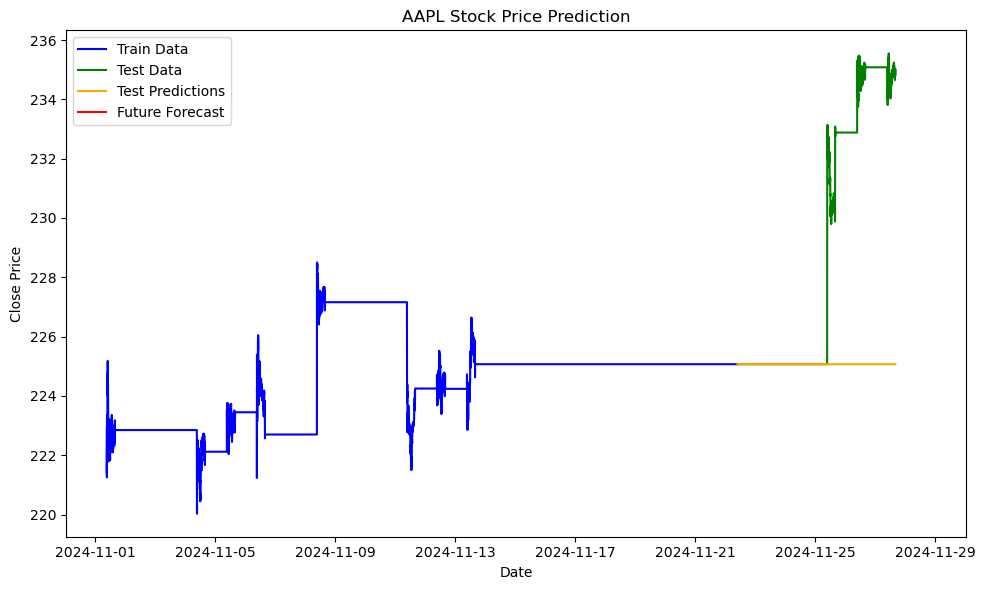

Plot saved at C:/Users/91940/Documents/Trade_buddy/data/model_outputs/AAPL_stock_prediction_20241128.png


In [29]:
stock_data = fetch_stock_data(TICKER)

# Ensure there are enough data points
if len(stock_data) < 20:  # Arbitrary threshold to ensure meaningful analysis
    print("Not enough data points for training and testing,",{len(stock_data)})
else:
    train, test = train_test_split(stock_data['close_price'])
    test_pred, future_pred, mse, mae, mape, rmspe = train_and_predict(train, test)
    #test_pred, future_pred, mse = train_and_predict_sarimax(train, test, p=2, d=1, q=1, P=1, D=1, Q=1, s=1440)
    print('Predictions computed')
    plot_predictions(train, test, test_pred, future_pred)

In [15]:
import getpass
import os

os.environ["GROQ_API_KEY"] = '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'

from langchain_groq import ChatGroq

chat_model = ChatGroq(model="llama3-8b-8192")

In [71]:
chat_model.invoke("how can my boyfriend relax?")

AIMessage(content="Helping your partner relax can bring you both closer and create a more harmonious relationship. Here are some ways you can help your boyfriend relax:\n\n1. **Encourage open communication**: Ask him how he's feeling and what's causing his stress. Sometimes, all he needs is someone to listen to him without judgment or criticism.\n2. **Create a calming environment**: Dim the lights, play soothing music, and maintain a comfortable temperature in your home. This can help him feel more relaxed and at ease.\n3. **Massage therapy**: Offer to give him a massage or take him to a professional massage therapist. Physical touch can be incredibly relaxing and releasing.\n4. **Aromatherapy**: Certain scents like lavender, chamomile, and vanilla can promote relaxation. You can use essential oils in a diffuser or apply them topically to his skin.\n5. **Yoga or meditation**: Suggest doing some yoga or meditation together. These practices can help reduce stress and anxiety.\n6. **Exerc

In [30]:
SOURCE =  f"""
The stock is {TICKER} and the 
Test Mean Squared Error (MSE): {mse}
Test Mean Absolute Error (MAE): {mae}
Test Mean Absolute Percentage Error (MAPE): {mape}
Test Root Mean Squared Percentage Error (RMSPE): {rmspe}
And for more context please find these data : {train},{test},{test_pred},{future_pred}
"""

In [50]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a world class stock analyst and a helpful assistant. Use the following context when responding:\n\n{context}."),
    ("human", "{question}")
])

rag_chain = rag_prompt | chat_model | StrOutputParser()

rag_chain.invoke({
    "question": "What do you think about the ARIMA model performance for this stock and whether you recommend buying?",
    "context": SOURCE
})

"Based on the ARIMA model performance metrics, I'd say the model has done a decent job of predicting the stock's behavior. The Mean Squared Error (MSE) of 33.99 indicates that the model's predictions are relatively close to the actual values, with an average deviation of around 3.78 (MAE). The Mean Absolute Percentage Error (MAPE) of 1.62% suggests that the model is accurate within a relatively small margin of error.\n\nThe Root Mean Squared Percentage Error (RMSPE) of 2.49% is also within an acceptable range, indicating that the model's predictions are reasonably accurate in terms of percentage error.\n\nOverall, I'd say the ARIMA model has performed well, and it's likely to provide useful insights for making investment decisions.\n\nAs for whether I recommend buying the stock, it depends on your risk tolerance, investment goals, and the overall market conditions. However, based on the model's performance, I would say that the stock appears to be a relatively stable and predictable in

In [55]:
def invoke_rag_prompt(context: str, question: str):
    """Invokes the RAG prompt with a given context and question."""
    rag_prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a world-class stock analyst and a helpful assistant. Use the following context when responding:\n\n{context}."),
        ("human", "{question}")
    ])
    rag_chain = rag_prompt | chat_model | StrOutputParser()
    return rag_chain.invoke({"context": context, "question": question})

def generate_context(mse, mae, mape, rmspe):
    """Generates the context string for the RAG model based on metrics."""
    return f"""
    Stock Analysis Report:
    - Model: ARIMA
    - MSE: {mse:.2f}
    - MAE: {mae:.2f}
    - MAPE: {mape:.2f}%
    - RMSPE: {rmspe:.2f}%
    """

In [56]:
SOURCE = generate_context(mse, mae, mape, rmspe)

In [57]:
rag_response = invoke_rag_prompt(SOURCE, "What do you think about the ARIMA model performance for this stock and whether you recommend buying?")

In [58]:
import yfinance as yf


stock = yf.Ticker("AAPL")  # Example: Apple Inc.
financials = stock.financials
balance_sheet = stock.balance_sheet
cash_flow = stock.cashflow
print(cash_flow)
info = stock.info  # Includes P/E ratio, dividend yield, etc.

print(info['trailingPE'])  # P/E Ratio
print(info['dividendYield'])  # Dividend Yield

                                                    2024-09-30  \
Free Cash Flow                                  108807000000.0   
Repurchase Of Capital Stock                     -94949000000.0   
Repayment Of Debt                                -9958000000.0   
Issuance Of Debt                                           0.0   
Issuance Of Capital Stock                                  NaN   
Capital Expenditure                              -9447000000.0   
Interest Paid Supplemental Data                            NaN   
Income Tax Paid Supplemental Data                26102000000.0   
End Cash Position                                29943000000.0   
Beginning Cash Position                          30737000000.0   
Changes In Cash                                   -794000000.0   
Financing Cash Flow                            -121983000000.0   
Cash Flow From Continuing Financing Activities -121983000000.0   
Net Other Financing Charges                      -5802000000.0   
Cash Divid

HTTPError: 404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v6/finance/quoteSummary/AAPL?modules=financialData&modules=quoteType&modules=defaultKeyStatistics&modules=assetProfile&modules=summaryDetail&ssl=true